# Post 09: What Do Free-Energy Estimators Assume?

This notebook is the presentation layer for the ninth tutorial. The reusable FEP, BAR, overlap, ESS, and figure logic lives in `src/kups_md_tutorials/`.


In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.estimators import load_estimator_summary
from kups_md_tutorials.figures import generate_post09_figures

## Configuration

The smoke and full profiles compare two-state Gaussian systems with known free-energy offsets. Increasing the mean shift lowers overlap while keeping the true free energy fixed.

In [3]:
for profile in ["smoke", "full"]:
    print(f"--- {profile} ---")
    print(json.dumps(json.loads(Path(f"configs/post-09/{profile}.json").read_text()), indent=2))

--- smoke ---
{
  "post": "09",
  "profile": "smoke",
  "title": "What Do Free-Energy Estimators Assume?",
  "estimator_experiment": {
    "temperature": 1.0,
    "sample_count": 4000,
    "seed": 2026071409,
    "cases": [
      {
        "name": "good_overlap",
        "mean_shift": 0.5,
        "true_delta_f": 0.8
      },
      {
        "name": "poor_overlap",
        "mean_shift": 2.5,
        "true_delta_f": 0.8
      }
    ]
  }
}
--- full ---
{
  "post": "09",
  "profile": "full",
  "title": "What Do Free-Energy Estimators Assume?",
  "estimator_experiment": {
    "temperature": 1.0,
    "sample_count": 50000,
    "seed": 2026071409,
    "cases": [
      {
        "name": "good_overlap",
        "mean_shift": 0.5,
        "true_delta_f": 0.8
      },
      {
        "name": "marginal_overlap",
        "mean_shift": 1.5,
        "true_delta_f": 0.8
      },
      {
        "name": "poor_overlap",
        "mean_shift": 3.0,
        "true_delta_f": 0.8
      }
    ]
  }
}


## Committed Results

The summary reports forward FEP, reverse FEP, BAR, overlap coefficients, and effective sample size fractions.

In [4]:
summary = load_estimator_summary(Path("results/post-09/full/estimator_summary.json"))
for case in summary.cases:
    print(case.case, "overlap=", round(case.overlap_coefficient, 3), "forward FEP error=", round(case.forward_fep_error, 3), "BAR error=", round(case.bar_error, 3), "ESS=", round(case.forward_weight_ess_fraction, 4))

good_overlap overlap= 0.803 forward FEP error= -0.002 BAR error= 0.0 ESS= 0.779
marginal_overlap overlap= 0.453 forward FEP error= 0.005 BAR error= 0.008 ESS= 0.0966
poor_overlap overlap= 0.134 forward FEP error= 0.047 BAR error= 0.033 ESS= 0.0027


## Figure

The full-profile figure is regenerated from committed compact outputs.

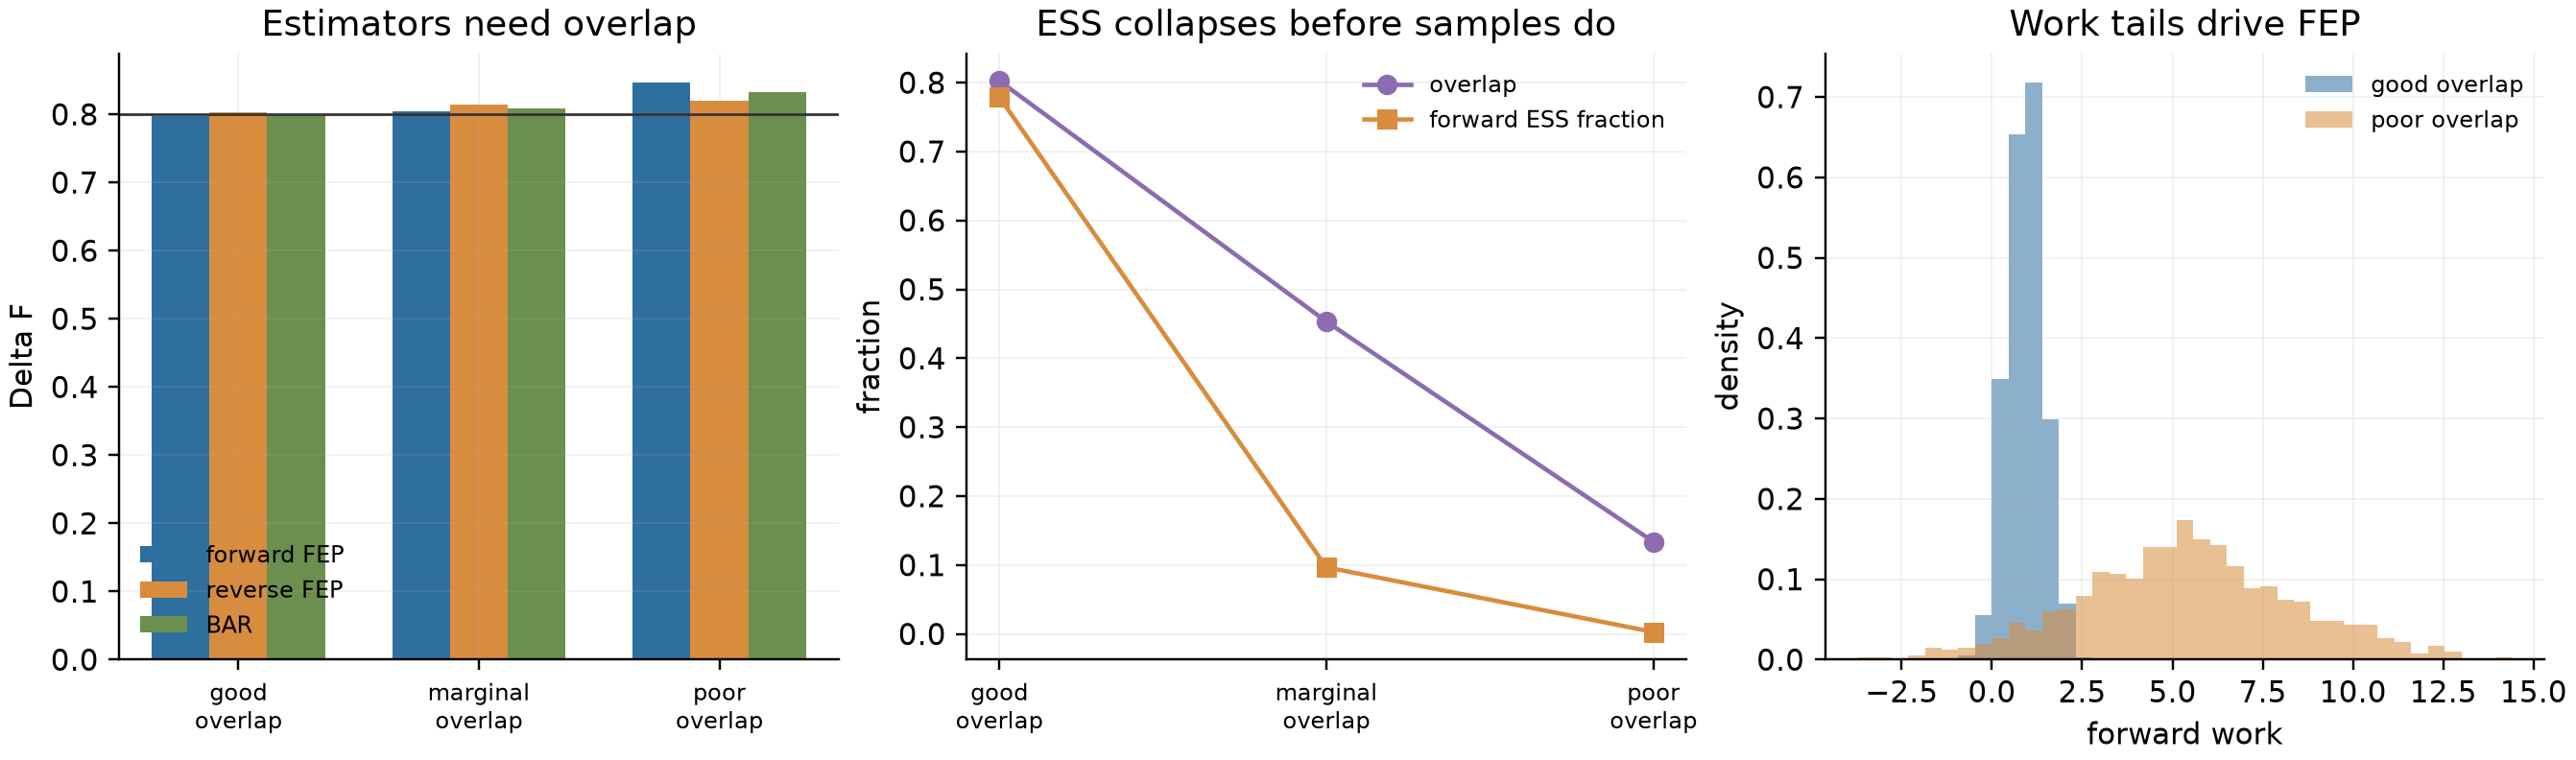

In [5]:
generate_post09_figures(
    result_dir=Path("results/post-09/full"),
    figure_dir=Path("figures/post-09"),
    snapshot_dir=Path("snapshots/post-09"),
    name="estimator_diagnostics_full",
)
display(Image(filename="figures/post-09/estimator_diagnostics_full.png"))